In [1]:
# Run this once per Colab session
!git clone https://github.com/adityarahi/Recommender-System-Project.git
%cd Recommender-System-Project
!pip install -r requirements.txt
!python data/download_data.py

Cloning into 'Recommender-System-Project'...
remote: Enumerating objects: 22, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 22 (delta 3), reused 22 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (22/22), 127.36 KiB | 2.36 MiB/s, done.
Resolving deltas: 100% (3/3), done.
/content/Recommender-System-Project
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 85.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 87.5 MB/s eta 0:00:00
Extracting...
Dataset ready at /content/Recommender-System-Project/data/raw/ml-100k/


# Model-Based CF — Matrix Factorization (SVD via SGD)

Train a latent-factor model from scratch with NumPy and evaluate:
- Hyperparameter sweep: n_factors ∈ {10, 50, 100}, lr ∈ {0.001, 0.005, 0.01}
- Convergence curves (train vs. val RMSE per epoch)
- Same evaluation metrics as notebook 02 for a fair comparison

In [2]:
import sys, os

# Works both locally (run from notebooks/) and on Google Colab (run from repo root)
_src = os.path.join('..', 'src') if os.path.isdir(os.path.join('..', 'src')) else 'src'
_data = os.path.join('..', 'data', 'processed') if os.path.isdir(os.path.join('..', 'data')) else os.path.join('data', 'processed')
sys.path.insert(0, _src)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import get_data
from model_based.matrix_factorization import MatrixFactorization
from evaluation.metrics import evaluate_predictions, evaluate_ranking, catalog_coverage

sns.set_theme(style='whitegrid')
%matplotlib inline

In [3]:
train, test, matrix, movies = get_data()
ALL_ITEMS = list(matrix.columns)
N_ITEMS = len(ALL_ITEMS)
K = 10
RELEVANCE_THRESHOLD = 4

test_relevant = (
    test[test['rating'] >= RELEVANCE_THRESHOLD]
    .groupby('user_id')['item_id']
    .apply(set)
    .to_dict()
)

train_rated = train.groupby('user_id')['item_id'].apply(set).to_dict()

## 1. Single training run with convergence plot

Epoch 5/30  train RMSE=0.9287  val RMSE=0.9549
Epoch 10/30  train RMSE=0.8895  val RMSE=0.9440
Epoch 15/30  train RMSE=0.8472  val RMSE=0.9377
Epoch 20/30  train RMSE=0.7904  val RMSE=0.9323
Epoch 25/30  train RMSE=0.7270  val RMSE=0.9314
Epoch 30/30  train RMSE=0.6664  val RMSE=0.9358


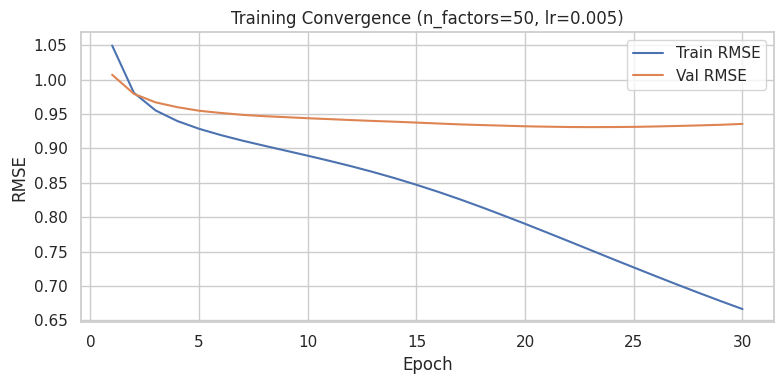

In [4]:
mf = MatrixFactorization(n_factors=50, n_epochs=30, lr=0.005, reg=0.02)
mf.fit(train, val=test)

epochs = range(1, len(mf.train_loss_) + 1)
plt.figure(figsize=(8, 4))
plt.plot(epochs, mf.train_loss_, label='Train RMSE')
plt.plot(epochs, mf.val_loss_, label='Val RMSE')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('Training Convergence (n_factors=50, lr=0.005)')
plt.legend()
plt.tight_layout()
plt.show()

## 2. Hyperparameter sweep

In [5]:
sweep_results = []

for n_factors in [10, 50, 100]:
    for lr in [0.001, 0.005, 0.01]:
        print(f'n_factors={n_factors}  lr={lr} ...', end=' ')
        model = MatrixFactorization(n_factors=n_factors, n_epochs=20, lr=lr, reg=0.02)
        model.fit(train)

        test['predicted'] = model.predict_batch(test)
        pred_metrics = evaluate_predictions(test, pred_col='predicted')

        recs = {}
        for uid in test['user_id'].unique():
            rated = train_rated.get(uid, set())
            recs[uid] = model.recommend(uid, ALL_ITEMS, rated_item_ids=rated, n=K)

        rank_metrics = evaluate_ranking(recs, test_relevant, k=K)
        cov = catalog_coverage(list(recs.values()), N_ITEMS)

        sweep_results.append({'n_factors': n_factors, 'lr': lr,
                               **pred_metrics, **rank_metrics, 'Coverage': cov})
        print(f"RMSE={pred_metrics['RMSE']:.4f}  NDCG@10={rank_metrics['NDCG@10']:.4f}")

sweep_df = pd.DataFrame(sweep_results)
sweep_df.sort_values('RMSE')

n_factors=10  lr=0.001 ... Epoch 5/20  train RMSE=1.0036
Epoch 10/20  train RMSE=0.9679
Epoch 15/20  train RMSE=0.9514
Epoch 20/20  train RMSE=0.9415
RMSE=0.9589  NDCG@10=0.0996
n_factors=10  lr=0.005 ... Epoch 5/20  train RMSE=0.9407
Epoch 10/20  train RMSE=0.9201
Epoch 15/20  train RMSE=0.9058
Epoch 20/20  train RMSE=0.8858
RMSE=0.9342  NDCG@10=0.0703
n_factors=10  lr=0.01 ... Epoch 5/20  train RMSE=0.9258
Epoch 10/20  train RMSE=0.8939
Epoch 15/20  train RMSE=0.8413
Epoch 20/20  train RMSE=0.7952
RMSE=0.9309  NDCG@10=0.0882
n_factors=50  lr=0.001 ... Epoch 5/20  train RMSE=1.0023
Epoch 10/20  train RMSE=0.9630
Epoch 15/20  train RMSE=0.9433
Epoch 20/20  train RMSE=0.9300
RMSE=0.9598  NDCG@10=0.0975
n_factors=50  lr=0.005 ... Epoch 5/20  train RMSE=0.9287
Epoch 10/20  train RMSE=0.8895
Epoch 15/20  train RMSE=0.8472
Epoch 20/20  train RMSE=0.7904
RMSE=0.9323  NDCG@10=0.0822
n_factors=50  lr=0.01 ... Epoch 5/20  train RMSE=0.8995
Epoch 10/20  train RMSE=0.8069
Epoch 15/20  train RMSE=

,n_factors,lr,RMSE,MAE,Precision@10,Recall@10,NDCG@10,Coverage
2,10,0.010,0.930937,0.729991,0.075186,0.051486,0.088198,0.164848
4,50,0.005,0.932283,0.735225,0.072004,0.048680,0.082190,0.110909
7,100,0.005,0.933477,0.735276,0.077094,0.057310,0.092182,0.142424
1,10,0.005,0.934232,0.737056,0.064687,0.042582,0.070314,0.061212
8,100,0.010,0.950167,0.745531,0.077200,0.058342,0.095504,0.251515
5,50,0.010,0.950604,0.744928,0.072641,0.055797,0.090220,0.250303
0,10,0.001,0.958876,0.760297,0.088335,0.068140,0.099552,0.027879
3,50,0.001,0.959817,0.761031,0.085684,0.064264,0.097461,0.036364
6,100,0.001,0.962206,0.763134,0.084093,0.065460,0.098977,0.049091


## 3. RMSE heatmap: n_factors vs lr

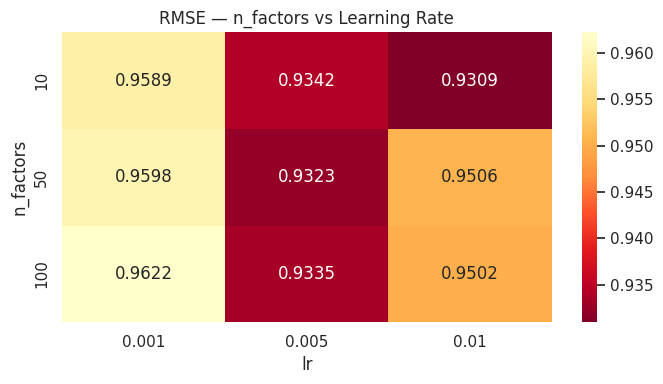

In [6]:
pivot = sweep_df.pivot(index='n_factors', columns='lr', values='RMSE')
plt.figure(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd_r')
plt.title('RMSE — n_factors vs Learning Rate')
plt.tight_layout()
plt.show()

## 4. Best model — full evaluation

In [7]:
best_row = sweep_df.loc[sweep_df['RMSE'].idxmin()]
print(f'Best config: n_factors={int(best_row.n_factors)}  lr={best_row.lr}')

best_mf = MatrixFactorization(
    n_factors=int(best_row.n_factors),
    n_epochs=30,
    lr=float(best_row.lr),
    reg=0.02
)
best_mf.fit(train, val=test)

test['predicted'] = best_mf.predict_batch(test)
pred_metrics = evaluate_predictions(test, pred_col='predicted')

recs = {}
for uid in test['user_id'].unique():
    rated = train_rated.get(uid, set())
    recs[uid] = best_mf.recommend(uid, ALL_ITEMS, rated_item_ids=rated, n=K)

rank_metrics = evaluate_ranking(recs, test_relevant, k=K)
cov = catalog_coverage(list(recs.values()), N_ITEMS)

mf_best = {'Model': 'Matrix Factorization', **pred_metrics, **rank_metrics, 'Coverage': cov}
pd.DataFrame([mf_best])

Best config: n_factors=10  lr=0.01
Epoch 5/30  train RMSE=0.9258  val RMSE=0.9444
Epoch 10/30  train RMSE=0.8939  val RMSE=0.9352
Epoch 15/30  train RMSE=0.8413  val RMSE=0.9271
Epoch 20/30  train RMSE=0.7952  val RMSE=0.9309
Epoch 25/30  train RMSE=0.7651  val RMSE=0.9387
Epoch 30/30  train RMSE=0.7448  val RMSE=0.9453


,Model,RMSE,MAE,Precision@10,Recall@10,NDCG@10,Coverage
0,Matrix Factorization,0.94528,0.736994,0.070308,0.049763,0.080149,0.233333


In [8]:
# Save for comparison notebook
pd.DataFrame([mf_best]).to_csv(os.path.join(_data, 'mf_best_results.csv'), index=False)

# Save sweep for heatmap reuse
sweep_df.to_csv(os.path.join(_data, 'mf_sweep_results.csv'), index=False)

## 5. Sample recommendations

In [9]:
SAMPLE_USER = 1
rated = train_rated.get(SAMPLE_USER, set())
top10 = best_mf.recommend(SAMPLE_USER, ALL_ITEMS, rated_item_ids=rated, n=10)

print(f'Top-10 recommendations for user {SAMPLE_USER} (Matrix Factorization):')
movies[movies['item_id'].isin(top10)][['item_id', 'title']]

Top-10 recommendations for user 1 (Matrix Factorization):


,item_id,title
134,135,2001: A Space Odyssey (1968)
168,169,"Wrong Trousers, The (1993)"
194,195,"Terminator, The (1984)"
197,198,Nikita (La Femme Nikita) (1990)
237,238,Raising Arizona (1987)
407,408,"Close Shave, A (1995)"
510,511,Lawrence of Arabia (1962)
645,646,Once Upon a Time in the West (1969)
1141,1142,When We Were Kings (1996)
1202,1203,Top Hat (1935)
